<a href="https://colab.research.google.com/github/davidpauloo/bellabeat-data-analysis/blob/main/notebooks/bellabeat_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [7]:
activity_df = pd.read_csv("dailyActivity_merged.csv")
sleep_df = pd.read_csv("sleepDay_merged.csv")

print("Activity Data Shape:", activity_df.shape)
print("Sleep Data Shape:", sleep_df.shape)

Activity Data Shape: (940, 15)
Sleep Data Shape: (413, 5)


In [8]:
# Checks and removes duplicates within the sleep data
print("Duplicate rows in sleep data before:", sleep_df.duplicated().sum())
sleep_df = sleep_df.drop_duplicates()
print("Duplicate rows in sleep data after:", sleep_df.duplicated().sum())

# Format dates to standard datetime format
activity_df["ActivityDate"] = pd.to_datetime(activity_df["ActivityDate"], format="%m/%d/%Y")
sleep_df["SleepDay"] = pd.to_datetime(sleep_df["SleepDay"], format="%m/%d/%Y %I:%M:%S %p")

# Rename SleepDay to ActivityDate so columns match for data merging
sleep_df = sleep_df.rename(columns={"SleepDay": "ActivityDate"})

# Add DayOfWeek column
activity_df["DayOfWeek"] = activity_df["ActivityDate"].dt.day_name()
print("\nCleaning complete! Data is ready for merging.")

Duplicate rows in sleep data before: 3
Duplicate rows in sleep data after: 0

Cleaning complete! Data is ready for merging.


In [9]:
merged_df = pd.merge(activity_df, sleep_df, on=["Id", "ActivityDate"], how="inner")
print("Merged DataFframe Shape:", merged_df.shape)
merged_df.head()

Merged DataFframe Shape: (410, 19)


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,DayOfWeek,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,Tuesday,1,327,346
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,Wednesday,2,384,407
2,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,Friday,1,412,442
3,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,Saturday,2,340,367
4,1503960366,2016-04-17,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,38,20,164,539,1728,Sunday,1,700,712


In [10]:
# Merge datasets on 'Id' and 'ActivityDate'
merged_df = pd.merge(activity_df, sleep_df, on=["Id", "ActivityDate"], how="inner")
print("Merged DataFrame Shape:", merged_df.shape)

# Checks unique user counts
print("Unique users in activity:", activity_df["Id"].nunique())
print("Unique users in sleep:", sleep_df["Id"].nunique())
print("Unique users in merged:", merged_df["Id"].nunique())

# Key summary statistics
merged_df[["TotalSteps", "Calories", "SedentaryMinutes", "VeryActiveMinutes", "TotalMinutesAsleep", "TotalTimeInBed"]].describe().round(2)

Merged DataFrame Shape: (410, 19)
Unique users in activity: 33
Unique users in sleep: 24
Unique users in merged: 24


,TotalSteps,Calories,SedentaryMinutes,VeryActiveMinutes,TotalMinutesAsleep,TotalTimeInBed
count,410.00,410.00,410.00,410.00,410.00,410.00
mean,8514.91,2389.30,712.10,25.05,419.17,458.48
std,4157.38,758.44,166.18,36.22,118.64,127.46
min,17.00,257.00,0.00,0.00,58.00,61.00
25%,5188.75,1841.00,631.25,0.00,361.00,403.75
50%,8913.00,2207.00,717.00,9.00,432.50,463.00
75%,11370.25,2920.00,782.75,38.00,490.00,526.00
max,22770.00,4900.00,1265.00,210.00,796.00,961.00


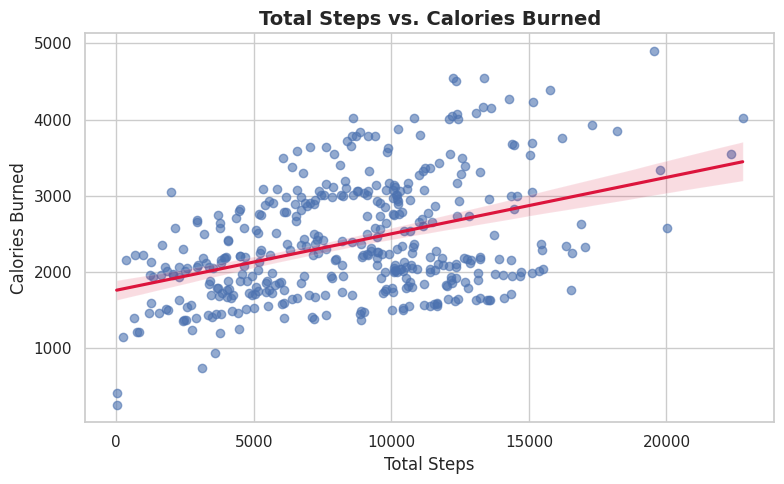

In [11]:
plt.figure(figsize=(8, 5))
sns.regplot(data=merged_df, x="TotalSteps", y="Calories", scatter_kws={"alpha":0.6}, line_kws={"color":"crimson"})
plt.title("Total Steps vs. Calories Burned", fontsize=14, fontweight="bold")
plt.xlabel("Total Steps")
plt.ylabel("Calories Burned")
plt.tight_layout()
plt.savefig("steps_vs_calories.png", dpi=300)
plt.show()

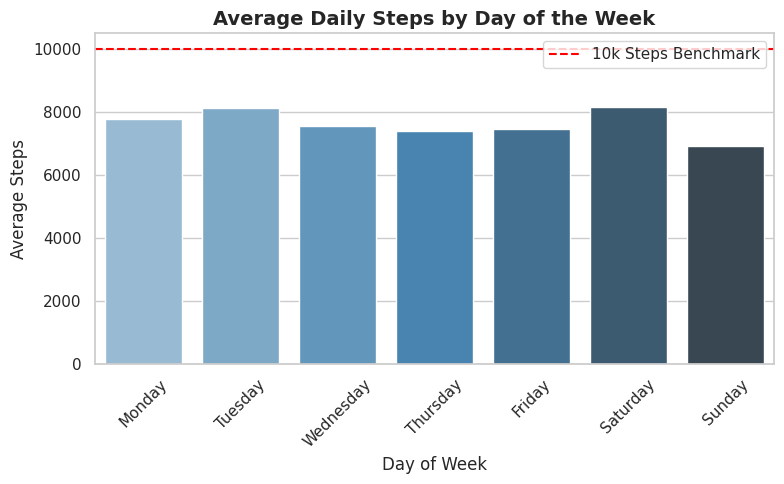

In [14]:
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_steps = activity_df.groupby("DayOfWeek")["TotalSteps"].mean().reindex(days_order)

plt.figure(figsize=(8, 5))
sns.barplot(x=daily_steps.index, y=daily_steps.values, hue=daily_steps.index, palette="Blues_d", legend=False)
plt.axhline(10000, color="red", linestyle="--", label="10k Steps Benchmark")
plt.title("Average Daily Steps by Day of the Week", fontsize=14, fontweight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Average Steps")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("daily_steps_trend.png", dpi=300)
plt.show()

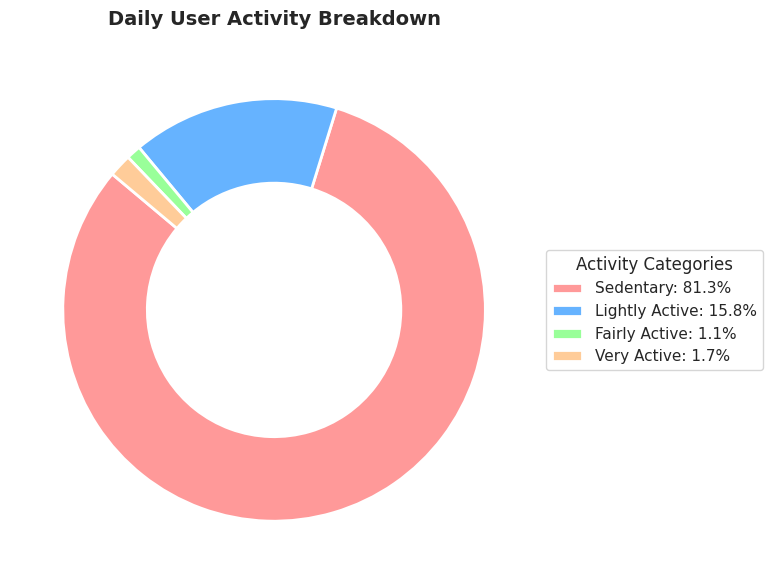

In [16]:
activity_cols = ["SedentaryMinutes", "LightlyActiveMinutes", "FairlyActiveMinutes", "VeryActiveMinutes"]
avg_minutes = activity_df[activity_cols].mean()
labels = ["Sedentary", "Lightly Active", "Fairly Active", "Very Active"]
colors = ["#ff9999", "#66b3ff", "#99ff99", "#ffcc99"]

# Calculate exact percentages for the legend
percentages = 100 * avg_minutes / avg_minutes.sum()
legend_labels = [f"{label}: {pct:.1f}%" for label, pct in zip(labels, percentages)]

plt.figure(figsize=(8, 6))

# Plot pie without text over the tiny slices
wedges, _ = plt.pie(
    avg_minutes,
    labels=None,
    autopct=None,
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2)  # Donut hole design
)

plt.legend(
    wedges,
    legend_labels,
    title="Activity Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=11,
    title_fontsize=12
)

plt.title("Daily User Activity Breakdown", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("activity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()